Device: cuda
Train size before limit: 809 | Val size: 4060 | Real size: 82
Label counts before limit - Train: Counter({0: 800, 1: 9}) | Val: Counter({0: 4000, 1: 60}) | Real: Counter({0: 54, 1: 28})

>>> After limiting SIMULATION TRAIN:
Train size: 809 | Label counts: Counter({0: 800, 1: 9})
Val size: 4060 | Label counts: Counter({0: 4000, 1: 60})
Real size: 82 | Label counts: Counter({0: 54, 1: 28})

>>> Few-shot REAL split:
Fixed real normal pool: 10 | Label counts: Counter({0: 10})
Selected real reference: 1 | Label counts: Counter({0: 1})
Real test: 72 | Label counts: Counter({0: 44, 1: 28})

>>> Fitting preprocessors on SIMULATION TRAIN only ...
X_train_proc shape: (809, 11)

Simulation train normals: 800 | train anomalies: 9
Simulation val normals: 4000 | val anomalies: 60
Real normal reference: 1
Final X_ref_fewshot: 801
Real test normals: 44 | real test anomalies: 28

>>> Fitting KNN on SIMULATION normals & anomalies ...

>>> PHASE 1: Model selection by ORIGINAL validation loss

/home/puma_qn/anaconda3/envs/torch_gpu/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


sigma_n=0.228861, sigma_m=1.258737, sigma_a=2.288614
Epoch 1/200 | Train loss=5.298543 | Val loss=5.252816
Epoch 20/200 | Train loss=4.841341 | Val loss=4.895433
Epoch 40/200 | Train loss=4.648702 | Val loss=4.802763
Epoch 60/200 | Train loss=4.564678 | Val loss=4.763621
Epoch 80/200 | Train loss=4.488178 | Val loss=4.764623
Epoch 100/200 | Train loss=4.368050 | Val loss=4.752540
Epoch 120/200 | Train loss=4.621780 | Val loss=4.734643
Epoch 140/200 | Train loss=4.462288 | Val loss=4.727987
Epoch 160/200 | Train loss=4.633178 | Val loss=4.724555
Epoch 180/200 | Train loss=4.565340 | Val loss=4.724823
Epoch 200/200 | Train loss=4.568720 | Val loss=4.724853

[1/1]
Best original VAL loss: 4.724555015563965
Best epoch: 160

>>> Best config selected by ORIGINAL validation loss:
{'latent_dim': 4, 'hid': 16, 'lr': 0.001, 'epochs': 200, 'weight_decay': 0.001, 'lambda1': 0.5, 'lambda2': 1, 'eta': 1, 'alpha': 0.5, 'w': 0.5, 'k1': 400, 'k2': 8, 'use_scheduler': True, 'sinkhorn_eps': 0.6, 'sinkhorn

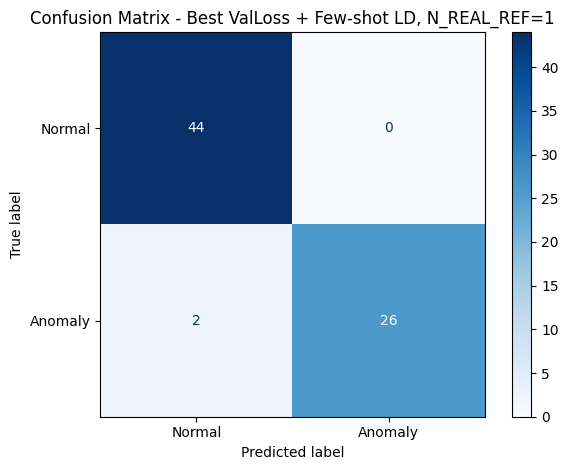

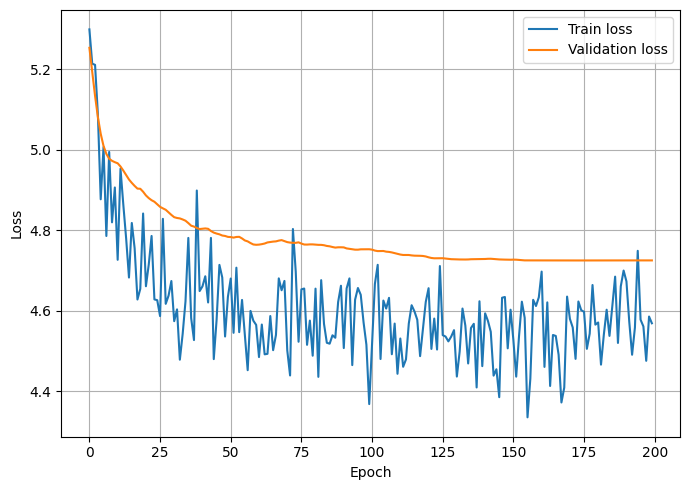

Saved: loss_curves_best_valloss_fewshot_LD_ref1.png
Saved: confusion_matrix_best_valloss_fewshot_LD_ref1.png
Saved: test_scores_best_valloss_fewshot_LD_ref1.csv
Saved: real_normal_reference_fewshot.csv
Saved: real_test_after_fewshot_split.csv
Saved: best_encoder_selected_by_original_valloss.pt
Saved: best_decoder_selected_by_original_valloss.pt

Training time: 1 min 02.83 s
Testing time : 0 min 00.38 s
Total time   : 1 min 03.21 s


In [1]:
# ============================================================
# AS-SRDT + Few-shot Real Normal Reference
# Local Density-Based Anomaly Score Normalization
#
# PHASE 1:
#   Train AS-SRDT on simulation
#   Select best model by ORIGINAL validation loss
#
# PHASE 2:
#   Load best model
#   Use few-shot real normal reference
#   Compute Local Density score
#   Select threshold on simulation validation
#   Test on remaining real data
#
# Required CSVs:
#   - label_pool.csv
#   - val_labeled_40.csv
#   - real_data.csv
# ============================================================

import random
from copy import deepcopy
from collections import Counter
from contextlib import contextmanager
import time

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    matthews_corrcoef,
    classification_report,
)

t0 = time.perf_counter()

# ============================================================
# 0) Settings
# ============================================================
SEED = 42
N_REAL_REF = 2

mpl.rcParams["axes.formatter.useoffset"] = False
mpl.rcParams["axes.formatter.use_locale"] = False
mpl.rcParams["axes.formatter.use_mathtext"] = False

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

@contextmanager
def preserve_rng_state():
    py_state = random.getstate()
    np_state = np.random.get_state()
    torch_cpu_state = torch.get_rng_state()
    torch_cuda_state = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None

    try:
        yield
    finally:
        random.setstate(py_state)
        np.random.set_state(np_state)
        torch.set_rng_state(torch_cpu_state)

        if torch_cuda_state is not None:
            torch.cuda.set_rng_state_all(torch_cuda_state)

# ============================================================
# 1) Load CSVs
# ============================================================
train_df = pd.read_csv("label_pool.csv")
val_df   = pd.read_csv("val_labeled_40.csv")
real_df  = pd.read_csv("real_data.csv")

FEATURES = [c for c in train_df.columns if c != "Label"]

X_train, y_train = train_df[FEATURES].copy(), train_df["Label"].copy()
X_val,   y_val   = val_df[FEATURES].copy(),   val_df["Label"].copy()
X_real,  y_real  = real_df[FEATURES].copy(),  real_df["Label"].copy()

print("Train size before limit:", len(y_train),
      "| Val size:", len(y_val),
      "| Real size:", len(y_real))

print("Label counts before limit - Train:", Counter(y_train),
      "| Val:", Counter(y_val),
      "| Real:", Counter(y_real))

# ============================================================
# 1b) Limit simulation train to 800 normal + 9 anomaly
# ============================================================
y_train_np_full = y_train.to_numpy().astype(int)

idx_all  = np.arange(len(y_train_np_full))
idx_norm = idx_all[y_train_np_full == 0]
idx_anom = idx_all[y_train_np_full == 1]

n_norm_target = 800
n_anom_target = 9

if len(idx_norm) < n_norm_target:
    print(f"[WARN] Train normal only {len(idx_norm)} < 800. Use {len(idx_norm)}.")
    n_norm_target = len(idx_norm)

if len(idx_anom) < n_anom_target:
    print(f"[WARN] Train anomaly only {len(idx_anom)} < 9. Use {len(idx_anom)}.")
    n_anom_target = len(idx_anom)

sel_norm = np.random.choice(idx_norm, size=n_norm_target, replace=False)
sel_anom = np.random.choice(idx_anom, size=n_anom_target, replace=False)

sel_idx = np.concatenate([sel_norm, sel_anom], axis=0)
np.random.shuffle(sel_idx)

X_train = X_train.iloc[sel_idx].copy()
y_train = y_train.iloc[sel_idx].copy()

print("\n>>> After limiting SIMULATION TRAIN:")
print("Train size:", len(y_train), "| Label counts:", Counter(y_train))
print("Val size:", len(y_val), "| Label counts:", Counter(y_val))
print("Real size:", len(y_real), "| Label counts:", Counter(y_real))

# ============================================================
# 2) Few-shot split real data
#    Step 1: reserve 10 fixed real normal samples
#    Step 2: choose N_REAL_REF from those 10 samples
#    Step 3: remaining real data is used for test
# ============================================================

N_REAL_POOL = 10
N_REAL_REF = 2

if N_REAL_REF not in [1, 2, 5, 10]:
    raise ValueError("N_REAL_REF must be one of [1, 2, 5, 10].")

y_real_np = y_real.to_numpy().astype(int)

idx_real_norm = np.flatnonzero(y_real_np == 0)
idx_real_anom = np.flatnonzero(y_real_np == 1)

if len(idx_real_norm) < N_REAL_POOL:
    raise ValueError(
        f"real_data.csv has only {len(idx_real_norm)} normal samples, "
        f"but N_REAL_POOL={N_REAL_POOL} is required."
    )

np.random.seed(SEED)

# ------------------------------------------------------------
# Step 1: reserve fixed 10 real normal samples
# ------------------------------------------------------------
real_pool_10_idx = np.random.choice(
    idx_real_norm,
    size=N_REAL_POOL,
    replace=False
)

# ------------------------------------------------------------
# Step 2: choose N_REAL_REF samples from the fixed 10 pool
# IMPORTANT:
# For N_REAL_REF = 1, 2, 5, 10,
# the selected samples are nested and consistent.
# ------------------------------------------------------------
real_ref_idx = real_pool_10_idx[:N_REAL_REF]

# ------------------------------------------------------------
# Step 3: real test = all real data except the fixed 10 normal pool
#          NOT except only N_REAL_REF
# ------------------------------------------------------------
real_test_norm_idx = np.array([
    i for i in idx_real_norm
    if i not in set(real_pool_10_idx)
])

real_test_anom_idx = idx_real_anom.copy()

real_test_idx = np.concatenate([
    real_test_norm_idx,
    real_test_anom_idx
])

X_real_pool_10 = X_real.iloc[real_pool_10_idx].copy()
y_real_pool_10 = y_real.iloc[real_pool_10_idx].copy()

X_real_ref = X_real.iloc[real_ref_idx].copy()
y_real_ref = y_real.iloc[real_ref_idx].copy()

X_real_test = X_real.iloc[real_test_idx].copy()
y_real_test = y_real.iloc[real_test_idx].copy()

print("\n>>> Few-shot REAL split:")
print("Fixed real normal pool:", len(y_real_pool_10), "| Label counts:", Counter(y_real_pool_10))
print("Selected real reference:", len(y_real_ref), "| Label counts:", Counter(y_real_ref))
print("Real test:", len(y_real_test), "| Label counts:", Counter(y_real_test))

pd.concat([X_real_pool_10, y_real_pool_10], axis=1).to_csv(
    "real_normal_pool_10_fixed.csv",
    index=False
)

pd.concat([X_real_ref, y_real_ref], axis=1).to_csv(
    f"real_normal_reference_from_pool10_ref{N_REAL_REF}.csv",
    index=False
)

pd.concat([X_real_test, y_real_test], axis=1).to_csv(
    "real_test_excluding_pool10.csv",
    index=False
)

# ============================================================
# 3) Preprocessing
#    Fit scaler ONLY on simulation train
# ============================================================
num_cols = [
    "Circuit breaker Open/Close Status",
    "Length",
    "heartbeat",
    "I-high VT",
    "I-high VT- Tran",
    "I-low VT- Tran",
    "I-amongst-feeders",
    "sqNum",
    "stNum",
    "dif_stNum",
    "dif_sqNum",
]

for c in num_cols:
    if c not in X_train.columns:
        raise ValueError(f"Column '{c}' not found. Check CSV column names.")

num_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
    ]
)

reg = Pipeline(steps=[("preprocessor", preprocessor)])

print("\n>>> Fitting preprocessors on SIMULATION TRAIN only ...")
reg.fit(X_train)

X_train_proc     = reg.transform(X_train)
X_val_proc       = reg.transform(X_val)
X_real_ref_proc  = reg.transform(X_real_ref)
X_real_test_proc = reg.transform(X_real_test)

print("X_train_proc shape:", X_train_proc.shape)

# ============================================================
# 4) Split normal/anomaly tensors
# ============================================================
y_train_np = y_train.to_numpy().astype(int)
y_val_np   = y_val.to_numpy().astype(int)
y_ref_np   = y_real_ref.to_numpy().astype(int)
y_test_np  = y_real_test.to_numpy().astype(int)

idx_n_tr  = np.flatnonzero(y_train_np == 0)
idx_a_tr  = np.flatnonzero(y_train_np == 1)

idx_n_val = np.flatnonzero(y_val_np == 0)
idx_a_val = np.flatnonzero(y_val_np == 1)

idx_n_ref = np.flatnonzero(y_ref_np == 0)

idx_n_te  = np.flatnonzero(y_test_np == 0)
idx_a_te  = np.flatnonzero(y_test_np == 1)

Xn_tr    = torch.from_numpy(X_train_proc[idx_n_tr]).float()
Xa_tr    = torch.from_numpy(X_train_proc[idx_a_tr]).float()

Xn_val_t = torch.from_numpy(X_val_proc[idx_n_val]).float()
Xa_val_t = torch.from_numpy(X_val_proc[idx_a_val]).float()

Xn_real_ref = torch.from_numpy(X_real_ref_proc[idx_n_ref]).float()

Xn_te = torch.from_numpy(X_real_test_proc[idx_n_te]).float()
Xa_te = torch.from_numpy(X_real_test_proc[idx_a_te]).float()

X_ref_fewshot = torch.cat([Xn_tr, Xn_real_ref], dim=0)

print("\nSimulation train normals:", Xn_tr.shape[0], "| train anomalies:", Xa_tr.shape[0])
print("Simulation val normals:", Xn_val_t.shape[0], "| val anomalies:", Xa_val_t.shape[0])
print("Real normal reference:", Xn_real_ref.shape[0])
print("Final X_ref_fewshot:", X_ref_fewshot.shape[0])
print("Real test normals:", Xn_te.shape[0], "| real test anomalies:", Xa_te.shape[0])

batch_size = 128

ld_loader_n = DataLoader(
    TensorDataset(Xn_tr),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

# ============================================================
# 5) KNN for intermediate generation
# ============================================================
Xn_tr_np = Xn_tr.numpy()
Xa_tr_np = Xa_tr.numpy()

K1_MAX = max(1, min(400, len(Xn_tr_np)))
K2_MAX = max(1, min(40, len(Xa_tr_np)))

knn_n = NearestNeighbors(n_neighbors=K1_MAX, algorithm="auto", n_jobs=-1)
knn_a = NearestNeighbors(n_neighbors=K2_MAX, algorithm="auto", n_jobs=-1)

print("\n>>> Fitting KNN on SIMULATION normals & anomalies ...")
knn_n.fit(Xn_tr_np)
knn_a.fit(Xa_tr_np)

# ============================================================
# 6) Intermediate generation
# ============================================================
@torch.no_grad()
def generate_intermediate_allpairs_filtered_with_indices(
    xb_n,
    Xa_all,
    knn_n,
    knn_a,
    w=0.5,
    k1=400,
    k2=40,
):
    if xb_n.numel() == 0 or Xa_all.numel() == 0:
        empty = xb_n[:0]
        return (
            empty,
            torch.empty((0,), dtype=torch.long, device=xb_n.device),
            torch.empty((0,), dtype=torch.long, device=xb_n.device),
        )

    B, D = xb_n.shape
    A = Xa_all.shape[0]

    xb_exp = xb_n[:, None, :]
    xa_exp = Xa_all[None, :, :]

    xp = w * xb_exp + (1.0 - w) * xa_exp

    d_self_n = torch.norm(xp - xb_exp, dim=2)
    d_self_a = torch.norm(xp - xa_exp, dim=2)

    xp_flat = xp.reshape(B * A, D)
    d_self_n_flat = d_self_n.reshape(B * A)
    d_self_a_flat = d_self_a.reshape(B * A)

    p_idx = torch.arange(B, device=xb_n.device).repeat_interleave(A)
    q_idx = torch.arange(A, device=xb_n.device).repeat(B)

    xp_cpu = xp_flat.detach().cpu().numpy()

    k1_eff = max(1, int(min(k1, knn_n._fit_X.shape[0])))
    k2_eff = max(1, int(min(k2, knn_a._fit_X.shape[0])))

    dn_all = knn_n.kneighbors(xp_cpu, n_neighbors=k1_eff, return_distance=True)[0]
    da_all = knn_a.kneighbors(xp_cpu, n_neighbors=k2_eff, return_distance=True)[0]

    d_k1 = torch.from_numpy(dn_all[:, k1_eff - 1]).to(xb_n.device)
    d_k2 = torch.from_numpy(da_all[:, k2_eff - 1]).to(xb_n.device)

    mask = (d_self_n_flat <= d_k1) & (d_self_a_flat <= d_k2)

    if not mask.any():
        empty = xb_n[:0]
        return (
            empty,
            torch.empty((0,), dtype=torch.long, device=xb_n.device),
            torch.empty((0,), dtype=torch.long, device=xb_n.device),
        )

    xmid = xp_flat[mask]
    I = p_idx[mask]
    J = q_idx[mask]

    return xmid, I, J

# ============================================================
# 7) Utils
# ============================================================
def sample_trunc_gauss(n, d, sigma, clip_mult=3.0, device="cpu"):
    z = torch.randn(n, d, device=device) * sigma

    norms = z.norm(dim=1, keepdim=True)
    max_r = clip_mult * sigma

    scale = torch.clamp(max_r / (norms + 1e-8), max=1.0)

    return z * scale

def sinkhorn_distance(x, y, epsilon=0.1, n_iters=50):
    C = torch.cdist(x, y, p=2)

    n, m = x.size(0), y.size(0)

    a = torch.full((n,), 1.0 / n, device=x.device)
    b = torch.full((m,), 1.0 / m, device=x.device)

    K = torch.exp(-C / epsilon)
    K = torch.clamp(K, min=1e-12)

    u = torch.ones_like(a) / n
    v = torch.ones_like(b) / m

    for _ in range(n_iters):
        u = a / (K @ v + 1e-8)
        v = b / (K.t() @ u + 1e-8)

    P = torch.outer(u, v) * K

    transport = torch.sum(P * C)

    return transport

def _best_f1_on_val_from_percentiles(scores_normal_val, scores_all_val, y_val, q_grid):
    best_f1 = -1.0
    best_q = None
    best_t = None

    for q in q_grid:
        t = np.quantile(scores_normal_val, q)

        y_pred = (scores_all_val > t).astype(int)

        f1 = f1_score(
            y_val,
            y_pred,
            average="binary",
            pos_label=1,
            zero_division=0,
        )

        if f1 > best_f1:
            best_f1 = f1
            best_q = q
            best_t = t

    return best_f1, best_q, best_t

# ============================================================
# 8) Local Density-Based Score Normalization
#    Used ONLY AFTER model selection
# ============================================================
def density_normalized_scores(
    f_model,
    X_ref,
    X_split,
    batch_size=512,
    eps=1e-8,
):
    f_model.eval()

    with torch.no_grad():
        Z_ref = f_model(X_ref.to(device)).detach()
        Z_split = f_model(X_split.to(device)).detach()

        D_ref = torch.cdist(Z_ref, Z_ref, p=2)
        D_ref.fill_diagonal_(float("inf"))

        density_ref = D_ref.min(dim=1).values
        density_ref = torch.clamp(density_ref, min=eps)

        scores = []

        for i in range(0, Z_split.size(0), batch_size):
            z_batch = Z_split[i:i + batch_size]

            D = torch.cdist(z_batch, Z_ref, p=2)
            D_scaled = D / density_ref.unsqueeze(0)

            s = D_scaled.min(dim=1).values
            scores.append(s.cpu())

        scores = torch.cat(scores, dim=0).numpy()

    return scores

def density_scores_for_split(f_model, X_ref, Xn_split, Xa_split):
    s_n = density_normalized_scores(f_model, X_ref, Xn_split)
    s_a = density_normalized_scores(f_model, X_ref, Xa_split)

    s_all = np.concatenate([s_n, s_a], axis=0)

    y_true = np.concatenate([
        np.zeros_like(s_n, dtype=int),
        np.ones_like(s_a, dtype=int),
    ], axis=0)

    return s_n, s_a, s_all, y_true

# ============================================================
# 9) Encoder / Decoder
# ============================================================
class EncoderNet(nn.Module):
    def __init__(self, in_dim, hid=64, z=8, dropout=0.0):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(in_dim, hid),
            nn.ReLU(),
            nn.Linear(hid, hid),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hid, z),
        )

    def forward(self, x):
        return self.net(x)

class DecoderNet(nn.Module):
    def __init__(self, out_dim, hid=64, z=8):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(z, hid),
            nn.ReLU(),
            nn.Linear(hid, hid),
            nn.ReLU(),
            nn.Linear(hid, out_dim),
        )

    def forward(self, z):
        return self.net(z)

# ============================================================
# 10) Validation loss
# ============================================================
sigma_n = 0.1
sigma_m = 0.5
sigma_a = 1.0

@torch.no_grad()
def compute_val_loss_once(
    f_model,
    g_model,
    Xn_val_batch,
    Xa_val_batch,
    Xa_tr_all,
    zdim,
    lam1,
    lam2,
    eta,
    alpha,
    w_mix,
    k1,
    k2,
    eps_sh,
    it_sh,
    mse_loss,
    smooth_l1,
):
    f_model.eval()
    g_model.eval()

    xb = Xn_val_batch.to(device)
    xa = Xa_val_batch.to(device)

    xmid, I, J = generate_intermediate_allpairs_filtered_with_indices(
        xb_n=xb,
        Xa_all=Xa_tr_all,
        knn_n=knn_n,
        knn_a=knn_a,
        w=w_mix,
        k1=k1,
        k2=k2,
    )

    zn = f_model(xb)
    za = f_model(xa)

    zmid = f_model(xmid) if xmid.numel() > 0 else None

    Z_n = sample_trunc_gauss(zn.size(0), zdim, sigma_n, device=device)
    Z_a = sample_trunc_gauss(za.size(0), zdim, sigma_a, device=device)

    loss_n = sinkhorn_distance(zn, Z_n, epsilon=eps_sh, n_iters=it_sh)
    loss_a = sinkhorn_distance(za, Z_a, epsilon=eps_sh, n_iters=it_sh) * lam1

    if zmid is not None and zmid.size(0) > 0:
        Z_m = sample_trunc_gauss(zmid.size(0), zdim, sigma_m, device=device)

        loss_mid = sinkhorn_distance(
            zmid,
            Z_m,
            epsilon=eps_sh,
            n_iters=it_sh,
        ) * lam2
    else:
        loss_mid = torch.tensor(0.0, device=device)

    recon = mse_loss(g_model(zn), xb) * eta

    if zmid is not None and zmid.size(0) > 0:
        s_mid = zmid.norm(dim=1) / sigma_n
        s_p   = zn[I].norm(dim=1) / sigma_n

        za_all = f_model(Xa_tr_all)
        s_q = za_all[J].norm(dim=1) / sigma_n

        target = w_mix * s_p + (1.0 - w_mix) * s_q

        lcons = smooth_l1(s_mid, target) * alpha
    else:
        lcons = torch.tensor(0.0, device=device)

    loss = loss_n + loss_a + loss_mid + recon + lcons

    return float(loss.item())

# ============================================================
# 11) Train one config
#     PHASE 1: select best epoch by ORIGINAL validation loss
# ============================================================
in_dim = Xn_tr.shape[1]
Xa_tr_all = Xa_tr.to(device)

def train_one_config_select_by_valloss(config):
    global sigma_n, sigma_a, sigma_m

    zdim = config.get("latent_dim", 16)
    lr   = config.get("lr", 1e-3)
    wd   = config.get("weight_decay", 1e-5)
    ep   = config.get("epochs", 50)

    lam1  = config.get("lambda1", 1.0)
    lam2  = config.get("lambda2", 1.0)
    eta   = config.get("eta", 1.0)
    alpha = config.get("alpha", 1.0)

    w_mix = config.get("w", 0.5)
    k1    = config.get("k1", 400)
    k2    = config.get("k2", 40)

    eps_sh = config.get("sinkhorn_eps", 0.1)
    it_sh  = config.get("sinkhorn_iters", 50)

    use_sched = config.get("use_scheduler", True)

    sigma_warmup_epochs = int(config.get("sigma_warmup_epochs", 10))
    nu_n = float(config.get("nu_n", 0.05))
    nu_a = float(config.get("nu_a", 0.05))
    gamma = float(config.get("gamma", 2.5))
    use_hat_sigma_a = bool(config.get("use_hat_sigma_a", False))
    clip_mult = float(config.get("clip_mult", 3.0))

    f_model = EncoderNet(
        in_dim=in_dim,
        hid=config.get("hid", 16),
        z=zdim,
        dropout=config.get("dropout", 0.0),
    ).to(device)

    g_model = DecoderNet(
        out_dim=in_dim,
        hid=config.get("hid", 16),
        z=zdim,
    ).to(device)

    opt = optim.Adam(
        list(f_model.parameters()) + list(g_model.parameters()),
        lr=lr,
        weight_decay=wd,
    )

    mse = nn.MSELoss()
    smooth_l1 = nn.SmoothL1Loss(beta=1.0)

    if use_sched:
        warmup_epochs = min(5, ep)
        eta_min = lr * 0.0001

        scheduler = torch.optim.lr_scheduler.SequentialLR(
            opt,
            schedulers=[
                torch.optim.lr_scheduler.LinearLR(
                    opt,
                    start_factor=0.1,
                    end_factor=1.0,
                    total_iters=warmup_epochs,
                ),
                torch.optim.lr_scheduler.CosineAnnealingLR(
                    opt,
                    T_max=max(1, ep - warmup_epochs),
                    eta_min=eta_min,
                ),
            ],
            milestones=[warmup_epochs],
        )
    else:
        scheduler = None

    # --------------------------------------------------------
    # Warm-up AE
    # --------------------------------------------------------
    if sigma_warmup_epochs > 0:
        print(f"\n>>> Sigma warm-up: {sigma_warmup_epochs} epoch(s)")

        f_model.train()
        g_model.train()

        for we in range(1, sigma_warmup_epochs + 1):
            run = 0.0
            nb = 0

            for (xb_cpu,) in ld_loader_n:
                xb = xb_cpu.to(device)

                zn = f_model(xb)
                recon = mse(g_model(zn), xb)

                opt.zero_grad()
                recon.backward()
                opt.step()

                run += float(recon.item())
                nb += 1

            if scheduler is not None:
                scheduler.step()

            if we == 1 or we == sigma_warmup_epochs:
                print(f"  warm-up epoch {we}/{sigma_warmup_epochs}: recon={run / max(1, nb):.6f}")

    # --------------------------------------------------------
    # Estimate sigmas once
    # --------------------------------------------------------
    print("\n>>> Sigma estimate ...")

    f_model.eval()

    with torch.no_grad():
        zn_all = f_model(Xn_tr.to(device))

        qn = min(max(1.0 - nu_n, 0.50), 0.999)
        rn = torch.quantile(zn_all.norm(dim=1), qn).item()

        za_all_full = f_model(Xa_tr_all)

        qa = min(max(1.0 - nu_a, 0.50), 0.999)
        ra = torch.quantile(za_all_full.norm(dim=1), qa).item()

    sig_n = float(rn / (np.sqrt(zdim) + 1e-12))
    hat_sig_a = float(ra / (np.sqrt(zdim) + 1e-12))

    if not use_hat_sigma_a:
        hat_sig_a = 0.0

    sig_a = float(max(hat_sig_a, gamma * sig_n))

    if sig_a <= sig_n:
        sig_a = sig_n * 1.10

    sig_m = (sig_n + sig_a) / 2.0

    sigma_n, sigma_a, sigma_m = sig_n, sig_a, sig_m

    print(f"sigma_n={sigma_n:.6f}, sigma_m={sigma_m:.6f}, sigma_a={sigma_a:.6f}")

    # --------------------------------------------------------
    # Main training
    # --------------------------------------------------------
    train_loss_curve = []
    val_loss_curve = []

    best_epoch_val_loss = float("inf")
    best_epoch_state = None
    best_epoch = None

    Bv = min(batch_size, Xn_val_t.size(0), Xa_val_t.size(0))

    if Bv <= 0:
        Xn_val_batch = None
        Xa_val_batch = None
    else:
        Xn_val_batch = Xn_val_t[:Bv].clone()
        Xa_val_batch = Xa_val_t[:Bv].clone()

    for e in range(1, ep + 1):
        f_model.train()
        g_model.train()

        running = 0.0
        nb = 0

        for (xb_cpu,) in ld_loader_n:
            xb = xb_cpu.to(device)

            xmid, I, J = generate_intermediate_allpairs_filtered_with_indices(
                xb_n=xb,
                Xa_all=Xa_tr_all,
                knn_n=knn_n,
                knn_a=knn_a,
                w=w_mix,
                k1=k1,
                k2=k2,
            )

            zn = f_model(xb)
            za_all = f_model(Xa_tr_all)

            zmid = f_model(xmid) if xmid.numel() > 0 else None

            Z_n = sample_trunc_gauss(
                zn.size(0),
                zdim,
                sigma_n,
                clip_mult=clip_mult,
                device=device,
            )

            Z_a = sample_trunc_gauss(
                za_all.size(0),
                zdim,
                sigma_a,
                clip_mult=clip_mult,
                device=device,
            )

            loss_n = sinkhorn_distance(zn, Z_n, epsilon=eps_sh, n_iters=it_sh)
            loss_a = sinkhorn_distance(za_all, Z_a, epsilon=eps_sh, n_iters=it_sh) * lam1

            if zmid is not None and zmid.size(0) > 0:
                Z_m = sample_trunc_gauss(
                    zmid.size(0),
                    zdim,
                    sigma_m,
                    clip_mult=clip_mult,
                    device=device,
                )

                loss_mid = sinkhorn_distance(
                    zmid,
                    Z_m,
                    epsilon=eps_sh,
                    n_iters=it_sh,
                ) * lam2
            else:
                loss_mid = torch.tensor(0.0, device=device)

            recon = mse(g_model(zn), xb) * eta

            if zmid is not None and zmid.size(0) > 0:
                s_mid = zmid.norm(dim=1) / sigma_n
                s_p   = zn[I].norm(dim=1) / sigma_n
                s_q   = za_all[J].norm(dim=1) / sigma_n

                target = w_mix * s_p + (1.0 - w_mix) * s_q

                lcons = smooth_l1(s_mid, target) * alpha
            else:
                lcons = torch.tensor(0.0, device=device)

            loss = loss_n + loss_a + loss_mid + recon + lcons

            opt.zero_grad()
            loss.backward()
            opt.step()

            running += float(loss.item())
            nb += 1

        if scheduler is not None:
            scheduler.step()

        train_loss = running / max(1, nb)
        train_loss_curve.append(train_loss)

        if Xn_val_batch is None:
            vloss = float("nan")
            val_loss_curve.append(vloss)
        else:
            with preserve_rng_state():
                torch.manual_seed(123456)

                if torch.cuda.is_available():
                    torch.cuda.manual_seed_all(123456)

                vloss = compute_val_loss_once(
                    f_model,
                    g_model,
                    Xn_val_batch,
                    Xa_val_batch,
                    Xa_tr_all=Xa_tr_all,
                    zdim=zdim,
                    lam1=lam1,
                    lam2=lam2,
                    eta=eta,
                    alpha=alpha,
                    w_mix=w_mix,
                    k1=k1,
                    k2=k2,
                    eps_sh=eps_sh,
                    it_sh=it_sh,
                    mse_loss=mse,
                    smooth_l1=smooth_l1,
                )

            val_loss_curve.append(vloss)

            if vloss < best_epoch_val_loss:
                best_epoch_val_loss = vloss
                best_epoch_state = (
                    deepcopy(f_model.state_dict()),
                    deepcopy(g_model.state_dict()),
                )
                best_epoch = e

        if e % 20 == 0 or e == 1 or e == ep:
            print(f"Epoch {e}/{ep} | Train loss={train_loss:.6f} | Val loss={vloss:.6f}")

    if best_epoch_state is None:
        best_epoch_state = (
            deepcopy(f_model.state_dict()),
            deepcopy(g_model.state_dict()),
        )

        if len(val_loss_curve) > 0:
            best_epoch_val_loss = float(val_loss_curve[-1])
        else:
            best_epoch_val_loss = float("nan")

        best_epoch = ep

    return (
        best_epoch_state,
        float(best_epoch_val_loss),
        int(best_epoch),
        train_loss_curve,
        val_loss_curve,
    )

# ============================================================
# 12) Search space
# ============================================================
search_space = [
    {
        "latent_dim": 4,
        "hid": 16,
        "lr": 1e-3,
        "epochs": 200,
        "weight_decay": 1e-3,
        "lambda1": 0.5,
        "lambda2": 1,
        "eta": 1,
        "alpha": 0.5,
        "w": 0.5,
        "k1": 400,
        "k2": 8,
        "use_scheduler": True,
        "sinkhorn_eps": 0.6,
        "sinkhorn_iters": 50,
        "dropout": 0.0,

        "sigma_warmup_epochs": 10,
        "nu_n": 0.05,
        "nu_a": 0.05,
        "gamma": 10,
        "use_hat_sigma_a": False,
        "clip_mult": 3.0,
    },
]

# ============================================================
# 13) PHASE 1: Select best model by original validation loss
# ============================================================
best_val_loss = float("inf")
best_state = None
best_cfg = None
best_epoch = None
best_train_curve = None
best_val_curve = None

print("\n>>> PHASE 1: Model selection by ORIGINAL validation loss")
print(f">>> Few-shot real normal reference size = {N_REAL_REF}")

for i, cfg in enumerate(search_space, 1):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    state_i, val_loss_i, epoch_i, tr_curve, va_curve = train_one_config_select_by_valloss(cfg)

    print(f"\n[{i}/{len(search_space)}]")
    print("Best original VAL loss:", val_loss_i)
    print("Best epoch:", epoch_i)

    if val_loss_i < best_val_loss:
        best_val_loss = val_loss_i
        best_cfg = deepcopy(cfg)
        best_state = deepcopy(state_i)
        best_epoch = epoch_i
        best_train_curve = tr_curve
        best_val_curve = va_curve

print("\n>>> Best config selected by ORIGINAL validation loss:")
print(best_cfg)
print("Best original VAL loss:", best_val_loss)
print("Best epoch:", best_epoch)

t1 = time.perf_counter()

assert best_cfg is not None
assert best_state is not None

# ============================================================
# 14) Load best model from PHASE 1
# ============================================================
zbest = best_cfg["latent_dim"]
hid = best_cfg.get("hid")

f_best = EncoderNet(
    in_dim=in_dim,
    hid=hid,
    z=zbest,
    dropout=best_cfg.get("dropout", 0.0),
).to(device)

g_best = DecoderNet(
    out_dim=in_dim,
    hid=hid,
    z=zbest,
).to(device)

f_best.load_state_dict(best_state[0])
g_best.load_state_dict(best_state[1])

f_best.eval()
g_best.eval()

torch.save(f_best.state_dict(), "best_encoder_selected_by_original_valloss.pt")
torch.save(g_best.state_dict(), "best_decoder_selected_by_original_valloss.pt")

print("\nSaved best model:")
print("best_encoder_selected_by_original_valloss.pt")
print("best_decoder_selected_by_original_valloss.pt")

# ============================================================
# 15) PHASE 2: Select threshold by Local Density score
# ============================================================
print("\n>>> PHASE 2: Threshold selection by FEW-SHOT LOCAL DENSITY score")

s_n_val_ld, s_a_val_ld, s_all_val_ld, y_true_val_ld = density_scores_for_split(
    f_best,
    X_ref=X_ref_fewshot,
    Xn_split=Xn_val_t,
    Xa_split=Xa_val_t,
)

coarse = np.linspace(0.80, 0.98, 10, endpoint=True)
fine   = np.linspace(0.98, 0.999, 15, endpoint=True)

q_grid = np.unique(np.concatenate([coarse, fine]))

best_f1_val_ld, best_q_ld, best_t_ld = _best_f1_on_val_from_percentiles(
    s_n_val_ld,
    s_all_val_ld,
    y_true_val_ld,
    q_grid,
)

print("Best LD VAL F1:", best_f1_val_ld)
print("Best q:", best_q_ld)
print("Best threshold:", best_t_ld)

# ============================================================
# 16) Final test on REAL data using LD threshold
# ============================================================
print("\n>>> FINAL TEST: Few-shot Local Density-Based Normalized Score")
print(f">>> Reference = simulation normal train ({Xn_tr.shape[0]}) + real normal few-shot ({Xn_real_ref.shape[0]})")
print(f">>> Test = remaining real normal ({Xn_te.shape[0]}) + all real anomaly ({Xa_te.shape[0]})")

s_n_te_ld, s_a_te_ld, s_all_te, y_true_te = density_scores_for_split(
    f_best,
    X_ref=X_ref_fewshot,
    Xn_split=Xn_te,
    Xa_split=Xa_te,
)

y_pred_te = (s_all_te > best_t_ld).astype(int)

auroc = roc_auc_score(y_true_te, s_all_te) if len(np.unique(y_true_te)) > 1 else float("nan")

f1_bin = f1_score(
    y_true_te,
    y_pred_te,
    average="binary",
    pos_label=1,
    zero_division=0,
)

mcc = matthews_corrcoef(y_true_te, y_pred_te)

print("\n=== TEST RESULTS: BEST MODEL BY ORIGINAL VAL LOSS + FEW-SHOT LD SCORE ===")
print("N_REAL_REF:", N_REAL_REF)
print("Best original VAL loss:", best_val_loss)
print("Best epoch:", best_epoch)
print("Best LD VAL F1:", best_f1_val_ld)
print("Best q:", best_q_ld)
print("Best threshold:", best_t_ld)
print("AUROC:", auroc)
print("Binary F1 anomaly=1:", f1_bin)
print("MCC:", mcc)

print("\nClassification report:")
print(classification_report(y_true_te, y_pred_te, zero_division=0))

cm = confusion_matrix(y_true_te, y_pred_te)

print("\nConfusion matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"],
)

disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - Best ValLoss + Few-shot LD, N_REAL_REF={N_REAL_REF}")
plt.tight_layout()
plt.savefig(f"confusion_matrix_best_valloss_fewshot_LD_ref{N_REAL_REF}.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# 17) Save scores and plots
# ============================================================
pd.DataFrame({
    "score_ld": s_all_te,
    "y_true": y_true_te,
    "y_pred": y_pred_te,
}).to_csv(f"test_scores_best_valloss_fewshot_LD_ref{N_REAL_REF}.csv", index=False)

plt.figure(figsize=(7, 5))
plt.plot(best_train_curve, label="Train loss")
plt.plot(best_val_curve, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"loss_curves_best_valloss_fewshot_LD_ref{N_REAL_REF}.png", dpi=300, bbox_inches="tight")
plt.show()

t2 = time.perf_counter()

print(f"Saved: loss_curves_best_valloss_fewshot_LD_ref{N_REAL_REF}.png")
print(f"Saved: confusion_matrix_best_valloss_fewshot_LD_ref{N_REAL_REF}.png")
print(f"Saved: test_scores_best_valloss_fewshot_LD_ref{N_REAL_REF}.csv")
print("Saved: real_normal_reference_fewshot.csv")
print("Saved: real_test_after_fewshot_split.csv")
print("Saved: best_encoder_selected_by_original_valloss.pt")
print("Saved: best_decoder_selected_by_original_valloss.pt")

def format_time(seconds):
    minutes = int(seconds // 60)
    secs = seconds % 60
    return f"{minutes:d} min {secs:05.2f} s"

print(f"\nTraining time: {format_time(t1 - t0)}")
print(f"Testing time : {format_time(t2 - t1)}")
print(f"Total time   : {format_time(t2 - t0)}")

In [ ]:
# ============================================================
# AS-SRDT (SSRDT-Sinkhorn + Anomaly Score Supervision) — PyTorch
# FULL-PAIRS Intermediate Generation + KNN Filtering (paper-style)
# + ADD: Score Supervision Consistency Loss (SmoothL1)
# + Keep: Model selection by BEST Binary F1 (anomaly=1) on VAL
#
# Required CSVs:
#   - label_pool.csv
#   - val_labeled_40.csv
#   - test_labeled_60.csv
# ============================================================

import random
from copy import deepcopy
from collections import Counter
from contextlib import contextmanager

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    matthews_corrcoef,
)
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    matthews_corrcoef,
)
import time

t0 = time.perf_counter()

# -----------------------------
# 0) Reproducibility & device
# -----------------------------
mpl.rcParams["axes.formatter.useoffset"] = False
mpl.rcParams["axes.formatter.use_locale"] = False
mpl.rcParams["axes.formatter.use_mathtext"] = False

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# Preserve RNG state so validation computations won't affect training
# =========================
@contextmanager
def preserve_rng_state():
    py_state = random.getstate()
    np_state = np.random.get_state()
    torch_cpu_state = torch.get_rng_state()
    if torch.cuda.is_available():
        torch_cuda_state = torch.cuda.get_rng_state_all()
    else:
        torch_cuda_state = None
    try:
        yield
    finally:
        random.setstate(py_state)
        np.random.set_state(np_state)
        torch.set_rng_state(torch_cpu_state)
        if torch_cuda_state is not None:
            torch.cuda.set_rng_state_all(torch_cuda_state)

# -----------------------------
# 1) Load CSVs
# -----------------------------
train_df = pd.read_csv("label_pool.csv")
val_df   = pd.read_csv("val_labeled_40.csv")
test_df  = pd.read_csv("Lab_data.csv")

FEATURES = [c for c in train_df.columns if c != "Label"]

X_train, y_train = train_df[FEATURES].copy(), train_df["Label"].copy()
X_val,   y_val   = val_df[FEATURES].copy(),   val_df["Label"].copy()
X_test,  y_test  = test_df[FEATURES].copy(),  test_df["Label"].copy()

print("Train size (before limit):", len(y_train),
      "| Val size:", len(y_val),
      "| Test size:", len(y_test))
print("Label counts (before limit) - Train:", Counter(y_train),
      "| Val:", Counter(y_val),
      "| Test:", Counter(y_test))

# -----------------------------
# 1b) Limit train to 800 normal + 9 anomaly
# -----------------------------
y_train_np_full = y_train.to_numpy().astype(int)
idx_all  = np.arange(len(y_train_np_full))
idx_norm = idx_all[y_train_np_full == 0]
idx_anom = idx_all[y_train_np_full == 1]

n_norm_target = 800
n_anom_target = 9

if len(idx_norm) < n_norm_target:
    print(f"[WARN] Train normal only {len(idx_norm)} < 800. Use {len(idx_norm)}.")
    n_norm_target = len(idx_norm)
if len(idx_anom) < n_anom_target:
    print(f"[WARN] Train anomaly only {len(idx_anom)} < 9. Use {len(idx_anom)}.")
    n_anom_target = len(idx_anom)

sel_norm = np.random.choice(idx_norm, size=n_norm_target, replace=False)
sel_anom = np.random.choice(idx_anom, size=n_anom_target, replace=False)
sel_idx  = np.concatenate([sel_norm, sel_anom], axis=0)
np.random.shuffle(sel_idx)

X_train = X_train.iloc[sel_idx].copy()
y_train = y_train.iloc[sel_idx].copy()

print("\n>>> After limiting TRAIN:")
print("Train size:", len(y_train), "| Label counts:", Counter(y_train))
print("Val size:", len(y_val), "| Label counts:", Counter(y_val))
print("Test size:", len(y_test), "| Label counts:", Counter(y_test))

# optional save
pd.concat([X_train, y_train], axis=1).to_csv("train_data_800_9.csv", index=False)
pd.concat([X_val,   y_val],   axis=1).to_csv("validation_data.csv", index=False)
pd.concat([X_test,  y_test],  axis=1).to_csv("test_data.csv", index=False)
print("Saved train_data_800_9.csv / validation_data.csv / test_data.csv")

# -----------------------------
# 2) Preprocessing (ColumnTransformer)
# -----------------------------
# num_cols = [
#     # "Circuit breaker Open/Close Status",
#     "Length", "heartbeat",
#     "sqNum", "stNum",
#     "dif_stNum", "dif_sqNum",
# ]

num_cols = [
    "Circuit breaker Open/Close Status",
    "Length", "heartbeat",
    "I-high VT", "I-high VT- Tran",
    "I-low VT- Tran",
    "I-amongst-feeders",
    "sqNum", "stNum",
    "dif_stNum", "dif_sqNum",
]

for c in num_cols:
    if c not in X_train.columns:
        raise ValueError(f"Column '{c}' not found in X_train. Check CSV column names.")

num_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
    ]
)

reg = Pipeline(steps=[("preprocessor", preprocessor)])

print("\n>>> Fitting preprocessors ...")
reg.fit(X_train)

X_train_proc = reg.transform(X_train)
X_val_proc   = reg.transform(X_val)
X_test_proc  = reg.transform(X_test)

print("X_train_proc shape:", X_train_proc.shape)

# -----------------------------
# 3) Split normal/anomaly tensors
# -----------------------------
y_train_np = y_train.to_numpy().astype(int)
y_val_np   = y_val.to_numpy().astype(int)
y_test_np  = y_test.to_numpy().astype(int)

idx_n_tr  = np.flatnonzero(y_train_np == 0)
idx_a_tr  = np.flatnonzero(y_train_np == 1)
idx_n_val = np.flatnonzero(y_val_np == 0)
idx_a_val = np.flatnonzero(y_val_np == 1)
idx_n_te  = np.flatnonzero(y_test_np == 0)
idx_a_te  = np.flatnonzero(y_test_np == 1)

Xn_tr    = torch.from_numpy(X_train_proc[idx_n_tr]).float()
Xa_tr    = torch.from_numpy(X_train_proc[idx_a_tr]).float()
Xn_val_t = torch.from_numpy(X_val_proc[idx_n_val]).float()
Xa_val_t = torch.from_numpy(X_val_proc[idx_a_val]).float()
Xn_te    = torch.from_numpy(X_test_proc[idx_n_te]).float()
Xa_te    = torch.from_numpy(X_test_proc[idx_a_te]).float()

print("\nTrain normals:", Xn_tr.shape[0], "| Train anomalies:", Xa_tr.shape[0])
print("Val normals:", Xn_val_t.shape[0], "| Val anomalies:", Xa_val_t.shape[0])
print("Test normals:", Xn_te.shape[0], "| Test anomalies:", Xa_te.shape[0])

batch_size = 128
ld_loader_n = DataLoader(
    TensorDataset(Xn_tr),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

# -----------------------------
# 4) FULL-DATASET KNN for Algorithm 1/2
# -----------------------------
Xn_tr_np = Xn_tr.numpy()
Xa_tr_np = Xa_tr.numpy()

K1_MAX = min(400, len(Xn_tr_np))
K2_MAX = min(40,  len(Xa_tr_np))
K1_MAX = max(1, K1_MAX)
K2_MAX = max(1, K2_MAX)

knn_n = NearestNeighbors(n_neighbors=K1_MAX, algorithm="auto", n_jobs=-1)
knn_a = NearestNeighbors(n_neighbors=K2_MAX, algorithm="auto", n_jobs=-1)

print("\n>>> Fitting KNN (FULL train set) on normals & anomalies ...")
knn_n.fit(Xn_tr_np)
knn_a.fit(Xa_tr_np)

# -----------------------------
# 5) Intermediate generation — ALL PAIRS + Algorithm 2 filtering
#    + return index mappings I, J  (needed for Lcons)
# -----------------------------
@torch.no_grad()
def generate_intermediate_allpairs_filtered_with_indices(
    xb_n: torch.Tensor,          # (B, D) normal batch
    Xa_all: torch.Tensor,        # (A, D) ALL anomalies in train
    knn_n: NearestNeighbors,
    knn_a: NearestNeighbors,
    w: float = 0.5,
    k1: int = 400,
    k2: int = 40,
):
    if xb_n.numel() == 0 or Xa_all.numel() == 0:
        empty = xb_n[:0]
        return empty, torch.empty((0,), dtype=torch.long, device=xb_n.device), torch.empty((0,), dtype=torch.long, device=xb_n.device)

    B, D = xb_n.shape
    A = Xa_all.shape[0]

    xb_exp = xb_n[:, None, :]                # (B,1,D)
    xa_exp = Xa_all[None, :, :]              # (1,A,D)
    xp = w * xb_exp + (1.0 - w) * xa_exp     # (B,A,D)

    d_self_n = torch.norm(xp - xb_exp, dim=2)  # (B,A)
    d_self_a = torch.norm(xp - xa_exp, dim=2)  # (B,A)

    xp_flat = xp.reshape(B * A, D)            # (B*A,D)
    d_self_n_flat = d_self_n.reshape(B * A)
    d_self_a_flat = d_self_a.reshape(B * A)

    p_idx = torch.arange(B, device=xb_n.device).repeat_interleave(A)  # (B*A,)
    q_idx = torch.arange(A, device=xb_n.device).repeat(B)             # (B*A,)

    xp_cpu = xp_flat.detach().cpu().numpy()

    k1_eff = int(min(k1, knn_n._fit_X.shape[0])); k1_eff = max(1, k1_eff)
    k2_eff = int(min(k2, knn_a._fit_X.shape[0])); k2_eff = max(1, k2_eff)

    dn_all = knn_n.kneighbors(xp_cpu, n_neighbors=k1_eff, return_distance=True)[0]
    da_all = knn_a.kneighbors(xp_cpu, n_neighbors=k2_eff, return_distance=True)[0]

    d_k1 = torch.from_numpy(dn_all[:, k1_eff - 1]).to(xb_n.device)
    d_k2 = torch.from_numpy(da_all[:, k2_eff - 1]).to(xb_n.device)

    mask = (d_self_n_flat <= d_k1) & (d_self_a_flat <= d_k2)

    if not mask.any():
        empty = xb_n[:0]
        return empty, torch.empty((0,), dtype=torch.long, device=xb_n.device), torch.empty((0,), dtype=torch.long, device=xb_n.device)

    xmid = xp_flat[mask]
    I = p_idx[mask]
    J = q_idx[mask]
    return xmid, I, J

# -----------------------------
# 6) Truncated Gaussians (target distributions)
# -----------------------------
def sample_trunc_gauss(n: int, d: int, sigma: float, clip_mult: float = 3.0, device: str | torch.device = "cpu"):
    z = torch.randn(n, d, device=device) * sigma
    norms = z.norm(dim=1, keepdim=True)
    max_r = clip_mult * sigma
    scale = torch.clamp(max_r / (norms + 1e-8), max=1.0)
    return z * scale

# -----------------------------
# 6b) SIGMA (will be set inside training by warm-up + quantile + margin-control)
#     Keep global vars so other functions remain unchanged.
# -----------------------------
# sigma_n = 0.1
# sigma_m = 0.5
# sigma_a = 1.0

# -----------------------------
# 7) Sinkhorn distance (entropic OT)
# -----------------------------
def sinkhorn_distance(x: torch.Tensor, y: torch.Tensor, epsilon: float = 0.1, n_iters: int = 50):
    C = torch.cdist(x, y, p=2)
    n, m = x.size(0), y.size(0)

    a = torch.full((n,), 1.0 / n, device=x.device)
    b = torch.full((m,), 1.0 / m, device=x.device)

    K = torch.exp(-C / epsilon)
    K = torch.clamp(K, min=1e-12)

    u = torch.ones_like(a) / n
    v = torch.ones_like(b) / m

    for _ in range(n_iters):
        u = a / (K @ v + 1e-8)
        v = b / (K.t() @ u + 1e-8)

    P = torch.outer(u, v) * K
    transport = torch.sum(P * C)
    return transport

# -----------------------------
# 8) Scoring + choose threshold by F1 on validation
# -----------------------------
def _scores_for_split(f_model, Xn_split, Xa_split, sigma_n_val=0.1):
    f_model.eval()
    with torch.no_grad():
        Xn_split = Xn_split.to(device)
        Xa_split = Xa_split.to(device)
        s_n = (f_model(Xn_split).norm(dim=1) / sigma_n_val).cpu().numpy()
        s_a = (f_model(Xa_split).norm(dim=1) / sigma_n_val).cpu().numpy()
    y_true = np.concatenate([np.zeros_like(s_n, dtype=int), np.ones_like(s_a, dtype=int)], axis=0)
    s_all  = np.concatenate([s_n, s_a], axis=0)
    return s_n, s_a, s_all, y_true

def _best_f1_on_val_from_percentiles(scores_normal_val, scores_all_val, y_val, q_grid):
    best_f1, best_q, best_t = -1.0, None, None
    for q in q_grid:
        t = np.quantile(scores_normal_val, q)
        y_pred = (scores_all_val > t).astype(int)
        f1 = f1_score(y_val, y_pred, average="binary", pos_label=1, zero_division=0)
        if f1 > best_f1:
            best_f1, best_q, best_t = f1, q, t
    return best_f1, best_q, best_t

# -----------------------------
# 9) Encoder/Decoder
# -----------------------------
class EncoderNet(nn.Module):
    def __init__(self, in_dim: int, hid: int = 64, z: int = 8, dropout: float = 0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hid), nn.ReLU(),
            nn.Linear(hid, hid), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hid, z),
        )
    def forward(self, x): return self.net(x)

class DecoderNet(nn.Module):
    def __init__(self, out_dim: int, hid: int = 64, z: int = 8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z, hid), nn.ReLU(),
            nn.Linear(hid, hid), nn.ReLU(),
            nn.Linear(hid, out_dim),
        )
    def forward(self, z): return self.net(z)

# -----------------------------
# 10) Validation loss computation (same formula) with RNG preserved
#     + include Lcons
# -----------------------------
@torch.no_grad()
def compute_val_loss_once(
    f_model, g_model,
    Xn_val_batch: torch.Tensor,
    Xa_val_batch: torch.Tensor,
    Xa_tr_all: torch.Tensor,
    zdim: int,
    lam1: float, lam2: float, eta: float, alpha: float,
    w_mix: float, k1: int, k2: int,
    eps_sh: float, it_sh: int,
    mse_loss: nn.Module,
    smooth_l1: nn.Module,
) -> float:
    f_model.eval()
    g_model.eval()

    xb = Xn_val_batch.to(device)
    xa = Xa_val_batch.to(device)

    xmid, I, J = generate_intermediate_allpairs_filtered_with_indices(
        xb_n=xb, Xa_all=Xa_tr_all, knn_n=knn_n, knn_a=knn_a, w=w_mix, k1=k1, k2=k2
    )

    zn = f_model(xb)
    za = f_model(xa)
    zmid = f_model(xmid) if xmid.numel() > 0 else None

    Z_n = sample_trunc_gauss(zn.size(0), zdim, sigma_n, device=device)
    Z_a = sample_trunc_gauss(za.size(0), zdim, sigma_a, device=device)

    loss_n = sinkhorn_distance(zn, Z_n, epsilon=eps_sh, n_iters=it_sh)
    loss_a = sinkhorn_distance(za, Z_a, epsilon=eps_sh, n_iters=it_sh) * lam1

    if zmid is not None and zmid.size(0) > 0:
        Z_m = sample_trunc_gauss(zmid.size(0), zdim, sigma_m, device=device)
        loss_mid = sinkhorn_distance(zmid, Z_m, epsilon=eps_sh, n_iters=it_sh) * lam2
    else:
        loss_mid = torch.tensor(0.0, device=device)

    recon = mse_loss(g_model(zn), xb) * eta

    if zmid is not None and zmid.size(0) > 0:
        s_mid = (zmid.norm(dim=1) / sigma_n)
        s_p   = (zn[I].norm(dim=1) / sigma_n)
        za_all = f_model(Xa_tr_all)
        s_q   = (za_all[J].norm(dim=1) / sigma_n)
        target = w_mix * s_p + (1.0 - w_mix) * s_q
        lcons = smooth_l1(s_mid, target) * alpha
    else:
        lcons = torch.tensor(0.0, device=device)

    loss = loss_n + loss_a + loss_mid + recon + lcons
    return float(loss.item())

# -----------------------------
# 11) Train 1 config + choose best q on VAL
#     + include Lcons in training
#     + SIGMA: data-driven sigma_n, margin-controlled sigma_a
# -----------------------------
in_dim = Xn_tr.shape[1]
Xa_tr_all = Xa_tr.to(device)  # ALL train anomalies for all-pairs mixing

def train_one_config_F1(config, f_init=None, g_init=None):
    global sigma_n, sigma_a, sigma_m  # keep other code unchanged

    zdim   = config.get("latent_dim", 16)
    lr     = config.get("lr", 1e-3)
    wd     = config.get("weight_decay", 1e-5)
    ep     = config.get("epochs", 50)
    lam1   = config.get("lambda1", 1.0)
    lam2   = config.get("lambda2", 1.0)
    eta    = config.get("eta", 1.0)
    alpha  = config.get("alpha", 1.0)

    w_mix  = config.get("w", 0.5)
    k1     = config.get("k1", 400)
    k2     = config.get("k2", 40)

    eps_sh = config.get("sinkhorn_eps", 0.1)
    it_sh  = config.get("sinkhorn_iters", 50)

    use_sched = config.get("use_scheduler", True)

    # ---------- SIGMA controls ----------
    sigma_warmup_epochs = int(config.get("sigma_warmup_epochs", 10))  # recon-only warm-up
    nu_n = float(config.get("nu_n", 0.05))  # normal tail fraction for quantile (1-nu_n)
    nu_a = float(config.get("nu_a", 0.05))  # anomaly quantile tail (tiny set)
    gamma = float(config.get("gamma", 2.5)) # margin factor: sigma_a >= gamma*sigma_n
    use_hat_sigma_a = bool(config.get("use_hat_sigma_a", False))  # include crude anomaly estimate or not
    clip_mult = float(config.get("clip_mult", 3.0))

    need_new = (f_init is None) or (g_init is None)
    if not need_new:
        try:
            need_new = (f_init.net[-1].out_features != zdim)
        except Exception:
            need_new = True

    if need_new:
        f_model = EncoderNet(in_dim=in_dim, hid=config.get("hid", 16), z=zdim, dropout=config.get("dropout", 0.0)).to(device)
        g_model = DecoderNet(out_dim=in_dim, hid=config.get("hid", 16), z=zdim).to(device)
    else:
        f_model = f_init
        g_model = g_init

    opt = optim.Adam(list(f_model.parameters()) + list(g_model.parameters()), lr=lr, weight_decay=wd)
    mse = nn.MSELoss()
    smooth_l1 = nn.SmoothL1Loss(beta=1.0)

    if use_sched:
        warmup_epochs = min(5, ep)
        eta_min = lr * 0.0001
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            opt,
            schedulers=[
                torch.optim.lr_scheduler.LinearLR(opt, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs),
                torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, ep - warmup_epochs), eta_min=eta_min),
            ],
            milestones=[warmup_epochs],
        )
    else:
        scheduler = None

    # ---------------------------
    # (A) Warm-up AE (recon-only on normals)
    # ---------------------------
    if sigma_warmup_epochs > 0:
        print(f"\n>>> [Sigma warm-up] recon-only for {sigma_warmup_epochs} epoch(s) on NORMAL train ...")
        f_model.train(); g_model.train()
        for we in range(1, sigma_warmup_epochs + 1):
            run = 0.0; nb = 0
            for (xb_cpu,) in ld_loader_n:
                xb = xb_cpu.to(device)
                zn = f_model(xb)
                recon = mse(g_model(zn), xb)
                opt.zero_grad()
                recon.backward()
                opt.step()
                run += float(recon.item()); nb += 1
            if scheduler is not None:
                scheduler.step()
            if we == 1 or we == sigma_warmup_epochs:
                print(f"  warm-up epoch {we}/{sigma_warmup_epochs}: recon={run/max(1,nb):.6f}")

    # ---------------------------
    # (B) Estimate sigma_n from NORMAL (data-driven),
    #     Estimate hat_sigma_a from anomalies (crude, optional),
    #     sigma_a = max(hat_sigma_a, gamma*sigma_n)  (margin-controlled)
    #     sigma_m = sqrt((sigma_n^2 + sigma_a^2)/2)  (t=0.5)
    #     Freeze sigmas for rest training
    # ---------------------------
    print("\n>>> [Sigma estimate] data-driven sigma_n + margin-controlled sigma_a (once) ...")
    f_model.eval(); g_model.eval()
    with torch.no_grad():
        zn_all = f_model(Xn_tr.to(device))
        qn = 1.0 - nu_n
        qn = min(max(qn, 0.50), 0.999)
        rn = torch.quantile(zn_all.norm(dim=1), qn).item()

        # crude anomaly estimate (optional)
        za_all_full = f_model(Xa_tr_all)
        qa = 1.0 - nu_a
        qa = min(max(qa, 0.50), 0.999)
        ra = torch.quantile(za_all_full.norm(dim=1), qa).item()

    sig_n = float(rn / (np.sqrt(zdim) + 1e-12))  # data-driven from NORMAL
    hat_sig_a = float(ra / (np.sqrt(zdim) + 1e-12))  # crude from few anomalies

    if not use_hat_sigma_a:
        hat_sig_a = 0.0

    sig_a = float(max(hat_sig_a, gamma * sig_n))  # margin-controlled

    # ensure strictly larger
    if sig_a <= sig_n:
        sig_a = sig_n * 1.10

    # sig_m = float(np.sqrt((sig_n ** 2 + sig_a ** 2) / 2.0))  # t=0.5
    sig_m = (sig_n  + sig_a ) / 2.0 # t=0.5

    sigma_n, sigma_a, sigma_m = sig_n, sig_a, sig_m

    print(f">>> [Sigma frozen] zdim={zdim}, nu_n={nu_n}, nu_a={nu_a}, gamma={gamma}, use_hat_sigma_a={use_hat_sigma_a}")
    print(f"    rn(q={qn:.3f})={rn:.6f}  => sigma_n={sigma_n:.6f}")
    print(f"    ra(q={qa:.3f})={ra:.6f}  => hat_sigma_a={hat_sig_a:.6f}")
    print(f"    sigma_a=max(hat_sigma_a, gamma*sigma_n)={sigma_a:.6f}")
    print(f"    sigma_m (t=0.5)={sigma_m:.6f}")

    # ---------------------------
    # (C) Main training uses frozen sigmas
    # ---------------------------
    train_loss_curve = []
    val_loss_curve   = []

    Bv = min(batch_size, Xn_val_t.size(0), Xa_val_t.size(0))
    if Bv <= 0:
        Xn_val_batch = None
        Xa_val_batch = None
    else:
        Xn_val_batch = Xn_val_t[:Bv].clone()
        Xa_val_batch = Xa_val_t[:Bv].clone()

    f_model.train()
    g_model.train()

    for e in range(1, ep + 1):
        running = 0.0
        nb = 0

        for (xb_cpu,) in ld_loader_n:
            xb = xb_cpu.to(device)

            xmid, I, J = generate_intermediate_allpairs_filtered_with_indices(
                xb_n=xb,
                Xa_all=Xa_tr_all,
                knn_n=knn_n,
                knn_a=knn_a,
                w=w_mix,
                k1=k1,
                k2=k2,
            )

            zn = f_model(xb)
            za_all = f_model(Xa_tr_all)
            zmid = f_model(xmid) if xmid.numel() > 0 else None

            Z_n = sample_trunc_gauss(zn.size(0), zdim, sigma_n, clip_mult=clip_mult, device=device)
            Z_a = sample_trunc_gauss(za_all.size(0), zdim, sigma_a, clip_mult=clip_mult, device=device)

            loss_n = sinkhorn_distance(zn, Z_n, epsilon=eps_sh, n_iters=it_sh)
            loss_a = sinkhorn_distance(za_all, Z_a, epsilon=eps_sh, n_iters=it_sh) * lam1

            if zmid is not None and zmid.size(0) > 0:
                Z_m = sample_trunc_gauss(zmid.size(0), zdim, sigma_m, clip_mult=clip_mult, device=device)
                loss_mid = sinkhorn_distance(zmid, Z_m, epsilon=eps_sh, n_iters=it_sh) * lam2
            else:
                loss_mid = torch.tensor(0.0, device=device)

            recon = mse(g_model(zn), xb) * eta

            if zmid is not None and zmid.size(0) > 0:
                s_mid = (zmid.norm(dim=1) / sigma_n)
                s_p   = (zn[I].norm(dim=1) / sigma_n)
                s_q   = (za_all[J].norm(dim=1) / sigma_n)
                target = w_mix * s_p + (1.0 - w_mix) * s_q
                lcons = smooth_l1(s_mid, target) * alpha
            else:
                lcons = torch.tensor(0.0, device=device)

            loss = loss_n + loss_a + loss_mid + recon + lcons

            opt.zero_grad()
            loss.backward()
            opt.step()

            running += float(loss.item())
            nb += 1

        if scheduler is not None:
            scheduler.step()

        train_loss_curve.append(running / max(1, nb))

        if Xn_val_batch is None:
            val_loss_curve.append(float("nan"))
        else:
            with preserve_rng_state():
                torch.manual_seed(123456)
                if torch.cuda.is_available():
                    torch.cuda.manual_seed_all(123456)

                vloss = compute_val_loss_once(
                    f_model, g_model,
                    Xn_val_batch, Xa_val_batch,
                    Xa_tr_all=Xa_tr_all,
                    zdim=zdim,
                    lam1=lam1, lam2=lam2, eta=eta, alpha=alpha,
                    w_mix=w_mix, k1=k1, k2=k2,
                    eps_sh=eps_sh, it_sh=it_sh,
                    mse_loss=mse,
                    smooth_l1=smooth_l1,
                )
            val_loss_curve.append(vloss)

        f_model.train(); g_model.train()

    # choose q* on validation by anomaly-F1
    s_n_val, s_a_val, s_all_val, y_true_val = _scores_for_split(f_model, Xn_val_t, Xa_val_t, sigma_n_val=sigma_n)
    coarse = np.linspace(0.80, 0.98, 10, endpoint=True)
    fine   = np.linspace(0.98, 0.999, 15, endpoint=True)
    q_grid = np.unique(np.concatenate([coarse, fine]))
    best_f1_val, best_q_val, best_t_val = _best_f1_on_val_from_percentiles(s_n_val, s_all_val, y_true_val, q_grid)

    return f_model, g_model, best_f1_val, float(best_q_val), float(best_t_val), train_loss_curve, val_loss_curve

# -----------------------------
# 12) Simple search (ONLY sigma-related knobs changed + you can tune gamma/nu_n)
# -----------------------------
search_space = [

        {
        "latent_dim": 4,
        "hid": 16,
        "lr": 1e-3,
        "epochs": 200,
        "weight_decay": 1e-3,
        "lambda1": 0.5,
        "lambda2": 1,
        "eta": 1,
        "alpha": 0.5,
        "w": 0.5,
        "k1": 400,
        "k2": 8,
        "use_scheduler": True,
        "sinkhorn_eps": 0.8,
            # "sinkhorn_eps": 0.60.8,,
        "sinkhorn_iters": 50,
        "dropout": 0.0,

        # ---------- SIGMA controls (NEW, per your "tôn trọng dữ liệu" idea) ----------
        "sigma_warmup_epochs": 10,  # warm-up AE epochs
        "nu_n": 0.05,               # sigma_n from NORMAL quantile (1-nu_n)
        "nu_a": 0.05,               # crude anomaly quantile (optional)
        "gamma": 10,               # margin factor: 2.0 ~ 3.0 (try 2.0, 2.5, 3.0)
        "use_hat_sigma_a": False,    # if False => sigma_a = gamma*sigma_n only
        "clip_mult": 3.0,
    },

]

best_val_f1 = -1.0
best_state  = None
best_cfg    = None
best_q      = None
best_t      = None
best_train_curve = None
best_val_curve   = None

print("\n>>> Model selection by Binary F1 (anomaly class) on VALIDATION (AS-SRDT: SSRDT+Lcons, ALL-PAIRS)")
for i, cfg in enumerate(search_space, 1):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    f_cand, g_cand, f1_val, q_val, t_val, tr_curve, va_curve = train_one_config_F1(cfg)
    print(f"[{i}/{len(search_space)}] F1_val_anomaly={f1_val:.4f} | q*={q_val:.6f} | t_val={t_val:.6f} | cfg={cfg}")

    if f1_val > best_val_f1:
        best_val_f1 = f1_val
        best_cfg = deepcopy(cfg)
        best_state = (deepcopy(f_cand.state_dict()), deepcopy(g_cand.state_dict()))
        best_q = float(q_val)
        best_t = float(t_val)
        best_train_curve = tr_curve
        best_val_curve   = va_curve

print("\n>>> Best config:", best_cfg)
print("Best Binary F1 (anomaly) on VAL:", best_val_f1, "| q* =", best_q, "| t_val =", best_t)

t1 = time.perf_counter()
assert best_cfg is not None and best_state is not None

# -----------------------------
# 13) Evaluate on TEST
#     CHANGED ONLY HERE IN SPIRIT:
#     Test (Lab_data.csv) -> use t_val directly
# -----------------------------
zbest = best_cfg["latent_dim"]
hid   = best_cfg.get("hid")

f_best = EncoderNet(in_dim=in_dim, hid=hid, z=zbest, dropout=best_cfg.get("dropout", 0.0)).to(device)
g_best = DecoderNet(out_dim=in_dim, hid=hid, z=zbest).to(device)
f_best.load_state_dict(best_state[0])
g_best.load_state_dict(best_state[1])
f_best.eval()
g_best.eval()

s_n_te, s_a_te, s_all_te, y_true_te = _scores_for_split(f_best, Xn_te, Xa_te, sigma_n_val=sigma_n)

# OLD:
# t_test = np.quantile(s_n_te, best_q)
# y_pred_te = (s_all_te > t_test).astype(int)

# NEW:
y_pred_te = (s_all_te > best_t).astype(int)

auroc = roc_auc_score(y_true_te, s_all_te) if len(np.unique(y_true_te)) > 1 else float("nan")
f1_bin = f1_score(y_true_te, y_pred_te, average="binary", pos_label=1, zero_division=0)
mcc = matthews_corrcoef(y_true_te, y_pred_te)

print("\n=== TEST RESULTS ===")
print("AUROC:", auroc)
print("Binary F1 (anom=1):", f1_bin)
print("MCC:", mcc)

t2 = time.perf_counter()

plt.figure(figsize=(7, 5))
plt.plot(best_train_curve, label="Train loss")
plt.plot(best_val_curve,   label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("loss_curves_AS_SRDT.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: loss_curves_AS_SRDT.png")

def format_time(seconds):
    minutes = int(seconds // 60)
    secs = seconds % 60
    return f"{minutes:d} min {secs:05.2f} s"

print(f"Training time   : {format_time(t1 - t0)}")
print(f"Testing time : {format_time(t2 - t1)}")